# CIVL3141 CNN tutorial 2

# UNet background introduction
UNet is created for conducting image segmentation, which is pretty effective for seperating those key features by utilizing convolutional methods.
Hence, UNet is a special type of **Convolutional Neural Network (CNN)** with similar components in CNN.
<div style="text-align: center;">
    <img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/1*zYrwp34DslR_9wLHMVAITg.png" width="90%" alt="image">
</div>
UNet is known for its conception of the shape of network visualization structure. It contains two paths:
- **contracting path**: this path aims to reduce the spatial dimensions of images and capture the related features from images.
- **expanding path**: this path is used to upstream the feature map to produce a related segmentation map using patterns leant in contracting path.

Now let's dive into the specific path to have a better understanding about the structure.
- **contracting path**: The contracting path uses a combination of convolution and pooling layers to extract and capture features within an image, while at the same time, reducing its spatial dimensions.
- - The blue arrows are the convolutional layer to extract features. In Block 1, the **conv 3x3** parts just conduct the extraction without modification in the channels of input information. Hence, the number of channels after Block 1 is still 64. Different from Block 1, in Block 2, 3, 4, and 5, the **conv 3x3** will change the parameters to expand the channels of information with doubled size, with pooling layers inside to reduce the required dimensions to decrease the time consumption. Through this path, the information will be contracted.
<div style="text-align: center;">
    <img src="https://miro.medium.com/v2/resize:fit:720/format:webp/1*Ofmoljm8odP3Od_PHNMdAg.png" width="50%" alt="image">
</div>

- **expanding path**: For the **conv 3x3** and pooling layers, these modules are in the opposite way to expand the dimensions and reduce channels to recover the original shape of information. But different from the contracting path, this path will add the previous contracting information by using the **shortcut skipping connections, which are gray arrows** in the figure to include the contracting path information. In this way, the expanding path can finally obtain the predicted image segmentation results based on given data.
<div style="text-align: center;">
    <img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/1*YezvSRtIOSLEeEwwyOMzgA.png" width="50%" alt="image">
</div>


### Since now you have already gone through the basic concept of UNet, you may now can start the image segmentation tutorial by completing the following steps as previous tutorial.


## 1. Environment setup

In [ ]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

## 2. Dataset preparation

In [ ]:
# setup dataset
class PotholeDataset(Dataset):
    def __init__(self, pothole_dir, normal_dir, transform=None):
        self.pothole_dir = pothole_dir
        self.normal_dir = normal_dir
        self.transform = transform

        if not os.path.exists(pothole_dir):
            raise ValueError(f"Pothole directory does not exist: {pothole_dir}")
        if not os.path.exists(normal_dir):
            raise ValueError(f"Normal directory does not exist: {normal_dir}")

        self.pothole_images = [os.path.join(pothole_dir, f) for f in os.listdir(pothole_dir) if f.endswith('.jpg')]
        self.normal_images = [os.path.join(normal_dir, f) for f in os.listdir(normal_dir) if f.endswith('.jpg')]
        self.images = self.pothole_images + self.normal_images
        self.labels = [1] * len(self.pothole_images) + [0] * len(self.normal_images)

        # check if images loaded
        if not self.images:
            raise ValueError("No valid .jpg images found in the directories!")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        image = cv2.imread(img_path)
        if image is None:
            raise ValueError(f"Failed to load image: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image_resized = cv2.resize(image, (256, 256))  # adjust the resolution of images

        if label == 1:  # if there are potholes
            img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            edges = cv2.Canny(img_gray, 50, 150)
            edges_resized = cv2.resize(edges, (256, 256), interpolation=cv2.INTER_NEAREST)  # adjust the boundary detection results
            pseudo_mask = cv2.dilate(edges_resized, np.ones((5, 5), np.uint8), iterations=1)
            pseudo_mask = (pseudo_mask > 0).astype(np.uint8)
        else:  # if no potholes
            pseudo_mask = np.zeros((256, 256), dtype=np.uint8)

        if self.transform:
            image_resized = self.transform(image_resized)

        return image_resized, torch.from_numpy(pseudo_mask).long()

## 3. UNet model

In [ ]:
# U-Net model
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=2):
        super(UNet, self).__init__()
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.ReLU(inplace=True)
            )
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.pool = nn.MaxPool2d(2, 2)
        self.bottleneck = conv_block(128, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)
        self.final = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))
        d2 = self.up2(b)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.dec1(d1)
        return self.final(d1)

## 4. Data loader, model, loss function, and optimizer setup

Shortcut the dataset to your google drive and revise the path accordingly:
such as **Mydrive**, so you don't have to change the directory (/drive/MyDrive/CIVL3141_code/CIVL3141/). Otherwise, please replace the directory(/drive/MyDrive/CIVL3141_code/CIVL3141/) with the path your shorcut added on (/drive/MyDrive/**yourfolder**/CIVL3141_code/CIVL3141/)


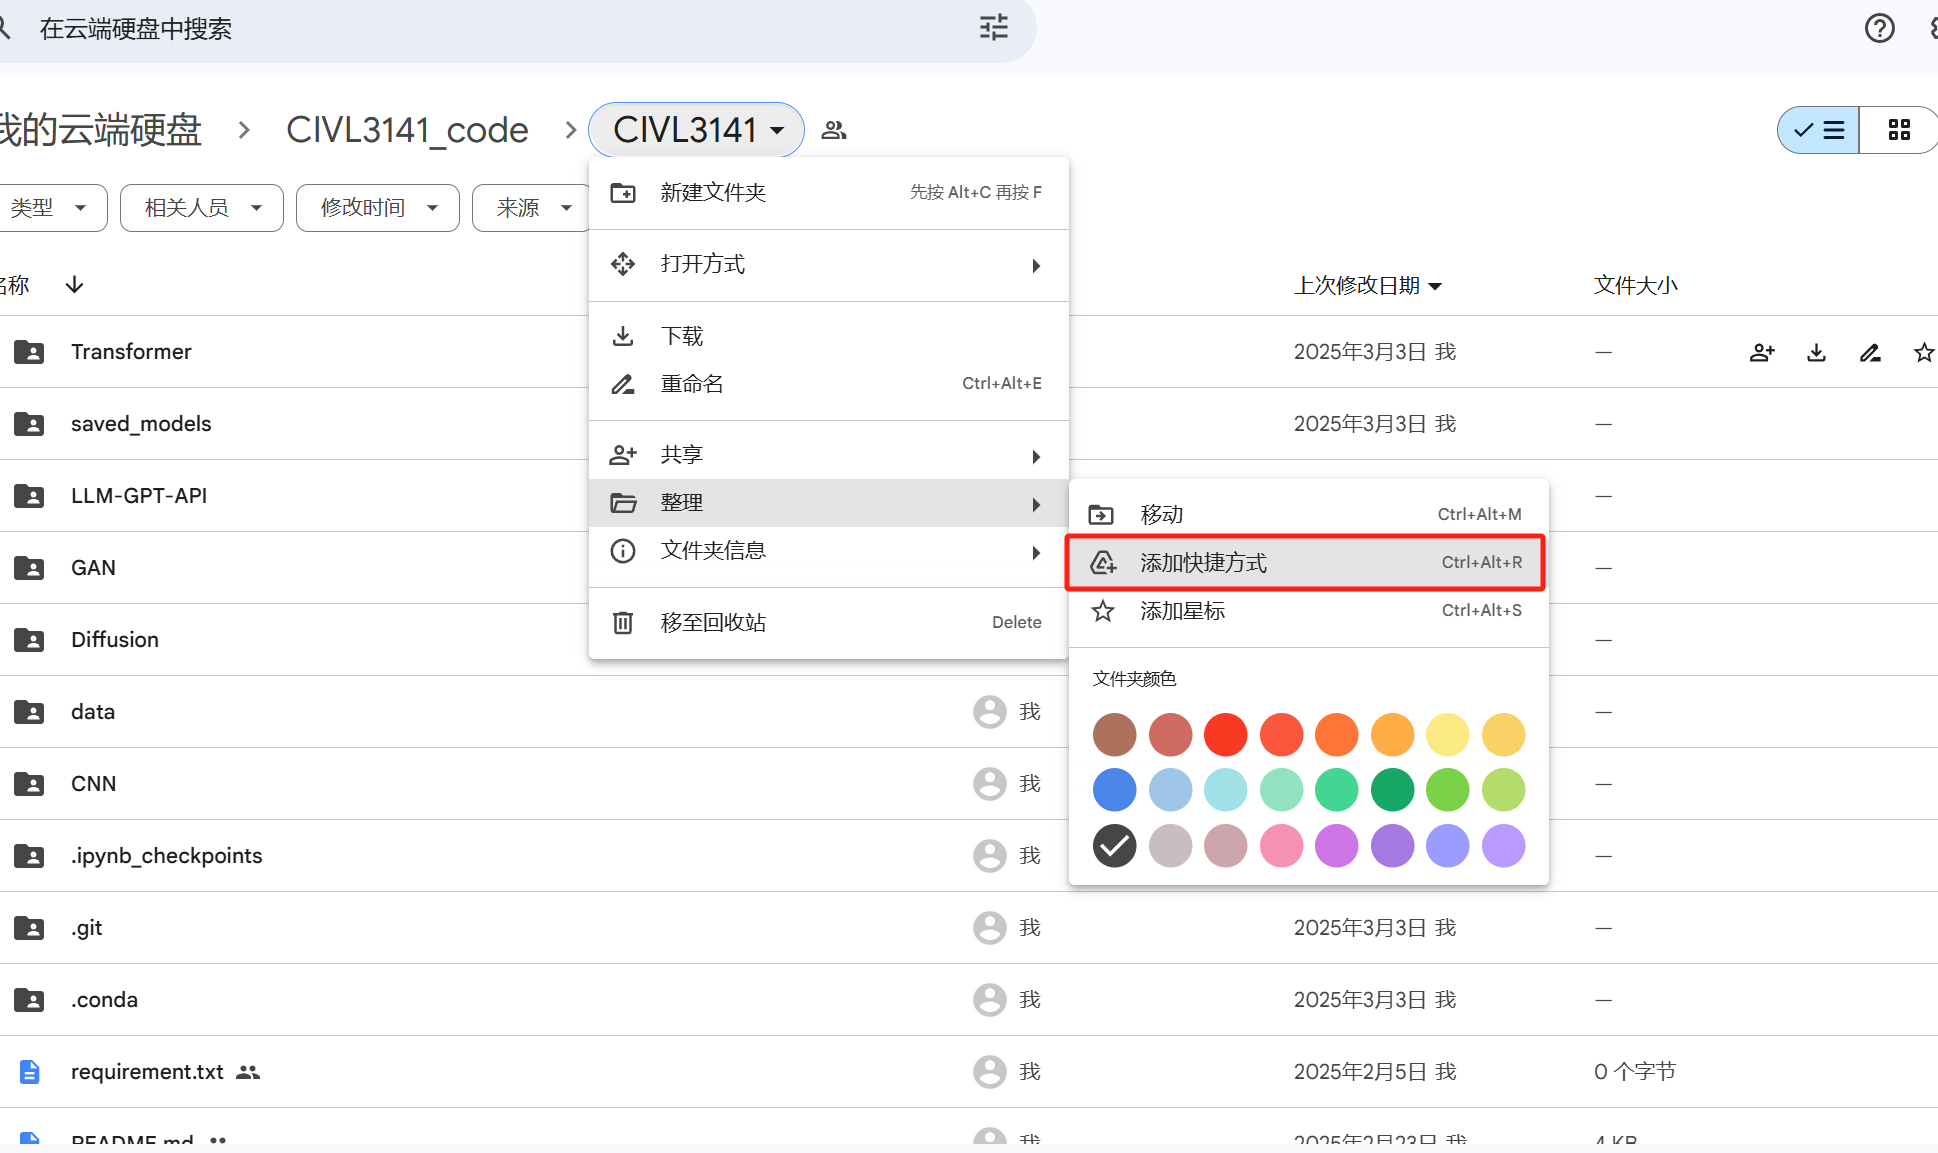


 Or upload the dataset by downloading the whole folder link shared in github: https://drive.google.com/drive/folders/1t64-EOTFa51KGf9rTSsfB1iv25pR0m7T?usp=sharing
 Remember to revise the directory and path if you upload to your folder.

In [ ]:
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
# data preparation

directory= '/content/drive/MyDrive/CIVL3141_code/CIVL3141'

os.chdir(directory)

pothole_dir = '/content/drive/MyDrive/CIVL3141_code/CIVL3141/CNN/data/pothole/hole'
normal_dir = '/content/drive/MyDrive/CIVL3141_code/CIVL3141/CNN/data/pothole/normal'

# pothole_dir = "/content/drive/MyDrive/CIVL3141_code/CIVL3141/CNN/data/pothole/hole"
# normal_dir = "/content/drive/MyDrive/CIVL3141_code/CIVL3141/CNN/data/pothole/normal"

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = PotholeDataset(pothole_dir, normal_dir, transform=transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=True)

# model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 5. Main training loop

In [ ]:
# training loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_pixels = 0

    for images, pseudo_masks in train_loader:
        images, pseudo_masks = images.to(device), pseudo_masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)  # [batch_size, 2, H, W]
        loss = criterion(outputs, pseudo_masks)
        loss.backward()
        optimizer.step()

        # accuracy calculation
        preds = torch.argmax(outputs, dim=1)  # [batch_size, H, W]
        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == pseudo_masks).item()
        total_pixels += pseudo_masks.numel()  # total pixes

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects / total_pixels * 100  # accuracy of pixes
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

Epoch [1/10], Loss: 0.5458, Accuracy: 71.50%
Epoch [2/10], Loss: 0.5249, Accuracy: 75.61%
Epoch [3/10], Loss: 0.4804, Accuracy: 77.93%
Epoch [4/10], Loss: 0.4408, Accuracy: 79.43%
Epoch [5/10], Loss: 0.4377, Accuracy: 80.14%
Epoch [6/10], Loss: 0.4063, Accuracy: 81.72%
Epoch [7/10], Loss: 0.3954, Accuracy: 82.36%
Epoch [8/10], Loss: 0.3965, Accuracy: 82.41%
Epoch [9/10], Loss: 0.4164, Accuracy: 81.19%
Epoch [10/10], Loss: 0.3892, Accuracy: 82.89%


## 6. Results visualization

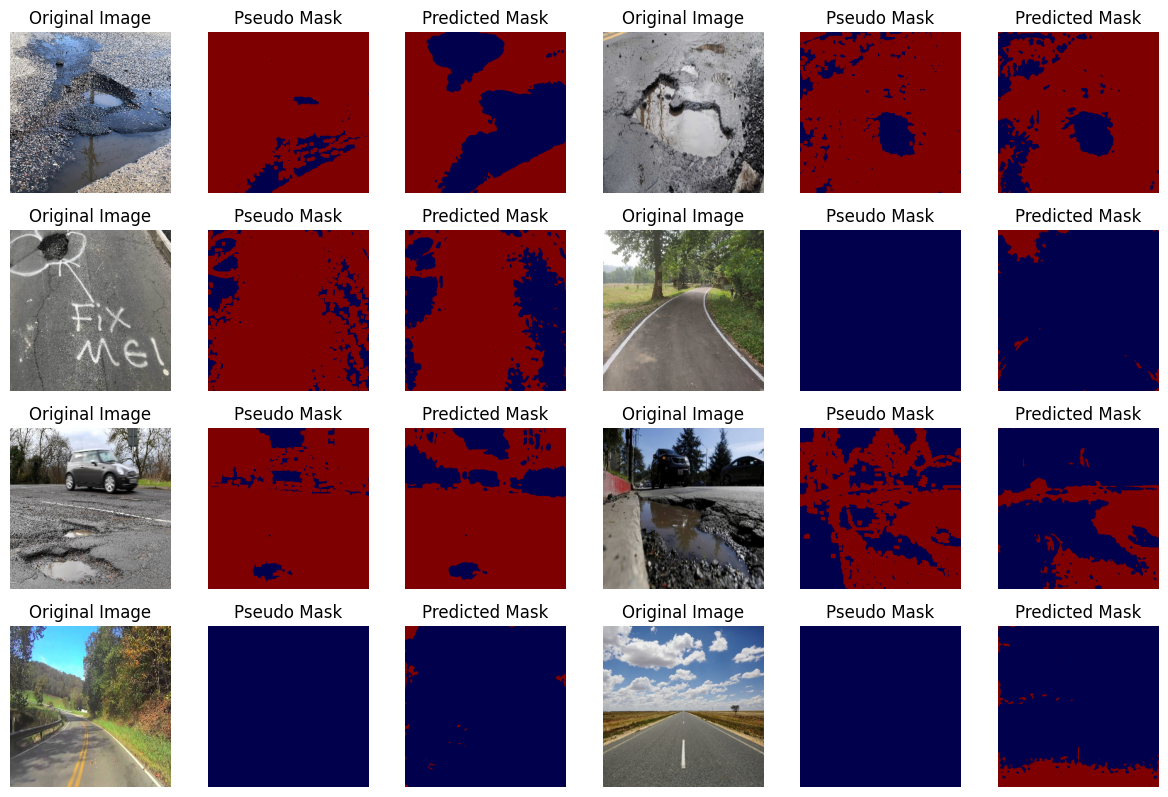

In [ ]:
num_samples_all = 8
test_loader2 = DataLoader(test_dataset, batch_size=num_samples_all, shuffle=True)
# testset visualization
def visualize_segmentation(model, test_loader, device, num_samples):
    model.eval()
    images, pseudo_masks = next(iter(test_loader))
    images, pseudo_masks = images.to(device), pseudo_masks.to(device)
    with torch.no_grad():
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

    plt.figure(figsize=(12, num_samples * 2))
    for i in range(num_samples):
        plt.subplot(num_samples, 6, i * 3 + 1)
        plt.imshow(images[i].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5)
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(num_samples, 6, i * 3 + 2)
        plt.imshow(pseudo_masks[i].cpu().numpy(), cmap='seismic')
        plt.title("Pseudo Mask")
        plt.axis('off')

        plt.subplot(num_samples, 6, i * 3 + 3)
        plt.imshow(preds[i], cmap='seismic')
        plt.title("Predicted Mask")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_segmentation(model, test_loader2, device, num_samples_all)

## Reference
- https://medium.com/@alejandro.itoaramendia/decoding-the-u-net-a-complete-guide-810b1c6d56d8
- https://www.kaggle.com/datasets/atulyakumar98/pothole-detection-dataset

# Real semantic segmentation dataset case

In [ ]:
class PotholeSegmentationDataset(Dataset):
    """
    坑洞分割数据集类
    支持YOLO格式的txt标签转换为分割mask
    """
    def __init__(self, root_dir, split='train', img_size=512, augment=False):
        """
        Args:
            root_dir: 数据集根目录
            split: 'train' 或 'valid'
            img_size: 图像 resize 尺寸
            augment: 是否使用数据增强
        """
        self.root_dir = root_dir
        self.split = split
        self.img_size = img_size
        self.augment = augment

        self.images_dir = os.path.join(root_dir, split, 'images')
        self.labels_dir = os.path.join(root_dir, split, 'labels')

        # 获取所有图像文件
        self.image_files = [f for f in os.listdir(self.images_dir)
                          if f.endswith(('.jpg', '.jpeg', '.png'))]

        # 图像变换
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.image_files)

    def yolo_txt_to_mask(self, txt_path, img_width, img_height):
        """
        将YOLO格式的txt标签转换为分割mask
        YOLO格式: class x_center y_center width height (归一化坐标)
        """
        mask = np.zeros((img_height, img_width), dtype=np.uint8)

        if not os.path.exists(txt_path):
            return mask

        with open(txt_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                # YOLO格式: class x_center y_center width height
                cls = int(parts[0])
                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])

                # 转换为像素坐标
                x_center_px = x_center * img_width
                y_center_px = y_center * img_height
                width_px = width * img_width
                height_px = height * img_height

                # 计算边界框
                x1 = int(x_center_px - width_px / 2)
                y1 = int(y_center_px - height_px / 2)
                x2 = int(x_center_px + width_px / 2)
                y2 = int(y_center_px + height_px / 2)

                # 确保坐标在图像范围内
                x1 = max(0, x1)
                y1 = max(0, y1)
                x2 = min(img_width, x2)
                y2 = min(img_height, y2)

                # 绘制mask (类别1为坑洞)
                if cls == 0:  # 假设类别0是坑洞
                    mask[y1:y2, x1:x2] = 1

        return mask

    def __getitem__(self, idx):
        # 获取图像路径
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)

        # 获取对应的标签文件路径
        label_name = os.path.splitext(img_name)[0] + '.txt'
        label_path = os.path.join(self.labels_dir, label_name)

        # 读取图像
        image = Image.open(img_path).convert('RGB')
        orig_width, orig_height = image.size

        # 数据增强
        if self.augment and self.split == 'train':
            # 随机水平翻转
            if random.random() > 0.5:
                image = F.hflip(image)
                # 注意：mask也需要相应翻转，这里简化处理

            # 随机亮度对比度调整
            if random.random() > 0.5:
                image = F.adjust_brightness(image, random.uniform(0.8, 1.2))
            if random.random() > 0.5:
                image = F.adjust_contrast(image, random.uniform(0.8, 1.2))

        # 调整图像大小
        image = image.resize((self.img_size, self.img_size), Image.BILINEAR)

        # 生成mask
        mask = self.yolo_txt_to_mask(label_path, orig_width, orig_height)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        # 图像变换
        image_tensor = self.transform(image)
        mask_tensor = torch.from_numpy(mask).long()

        return image_tensor, mask_tensor, img_name


def get_dataloaders(root_dir, batch_size=8, img_size=512, num_workers=4):
    """
    创建训练和验证数据加载器
    """
    train_dataset = PotholeSegmentationDataset(
        root_dir=root_dir,
        split='train',
        img_size=img_size,
        augment=True
    )

    valid_dataset = PotholeSegmentationDataset(
        root_dir=root_dir,
        split='valid',
        img_size=img_size,
        augment=False
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    valid_loader = DataLoader(
        valid_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    return train_loader, valid_loader, train_dataset, valid_dataset

In [ ]:
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
from torchvision import transforms
from torchvision.transforms import functional as F
import random

class DiceLoss(nn.Module):
    """Dice Loss for segmentation"""
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = torch.softmax(pred, dim=1)
        pred = pred[:, 1, :, :]  # 取前景类别
        target = target.float()

        intersection = (pred * target).sum()
        union = pred.sum() + target.sum()

        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice


class CombinedLoss(nn.Module):
    """CrossEntropy + Dice Loss"""
    def __init__(self, ce_weight=1.0, dice_weight=1.0):
        super(CombinedLoss, self).__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

    def forward(self, pred, target):
        ce_loss = self.ce(pred, target)
        dice_loss = self.dice(pred, target)
        return self.ce_weight * ce_loss + self.dice_weight * dice_loss


def train_model(model, train_loader, valid_loader, device, epochs=50,
                lr=1e-3, save_dir='checkpoints', log_dir='logs'):
    """
    训练模型
    """
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(log_dir, exist_ok=True)

    writer = SummaryWriter(log_dir)

    criterion = CombinedLoss(ce_weight=1.0, dice_weight=1.0)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5,
    )

    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    val_dices = []

    for epoch in range(epochs):
        print(f'\nEpoch {epoch+1}/{epochs}')
        print('-' * 50)

        # Training phase
        model.train()
        running_loss = 0.0

        pbar = tqdm(train_loader, desc='Training')
        for images, masks, _ in pbar:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_dice = 0.0

        with torch.no_grad():
            for images, masks, _ in tqdm(valid_loader, desc='Validating'):
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                loss = criterion(outputs, masks)

                val_loss += loss.item() * images.size(0)

                # Calculate Dice score
                pred = torch.argmax(outputs, dim=1)
                intersection = (pred * masks).sum()
                union = pred.sum() + masks.sum()
                dice = (2. * intersection + 1e-6) / (union + 1e-6)
                val_dice += dice.item() * images.size(0)

        epoch_val_loss = val_loss / len(valid_loader.dataset)
        epoch_val_dice = val_dice / len(valid_loader.dataset)

        val_losses.append(epoch_val_loss)
        val_dices.append(epoch_val_dice)

        scheduler.step(epoch_val_loss)

        # Logging
        writer.add_scalar('Loss/Train', epoch_train_loss, epoch)
        writer.add_scalar('Loss/Validation', epoch_val_loss, epoch)
        writer.add_scalar('Metrics/Dice', epoch_val_dice, epoch)

        print(f'Train Loss: {epoch_train_loss:.4f}')
        print(f'Val Loss: {epoch_val_loss:.4f}')
        print(f'Val Dice: {epoch_val_dice:.4f}')

        # Save best model
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': epoch_val_loss,
                'val_dice': epoch_val_dice,
            }, os.path.join(save_dir, 'best_model.pth'))
            print(f'✓ Best model saved!')

        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }, os.path.join(save_dir, f'checkpoint_epoch_{epoch+1}.pth'))

    writer.close()

    # Plot training curves
    plot_training_curves(train_losses, val_losses, val_dices, log_dir)

    return model


def plot_training_curves(train_losses, val_losses, val_dices, save_dir):
    """绘制训练曲线"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(train_losses, label='Train Loss', linewidth=2)
    ax1.plot(val_losses, label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training & Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(val_dices, color='green', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Dice Score')
    ax2.set_title('Validation Dice Score')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'training_curves.png'), dpi=150)
    plt.close()
    print(f'Training curves saved to {save_dir}/training_curves.png')


if __name__ == '__main__':

    # Configuration
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    DATASET_ROOT = 'CNN/data/Pothole_Segmentation_dataset'
    BATCH_SIZE = 8
    IMG_SIZE = 512
    EPOCHS = 50
    LEARNING_RATE = 1e-3

    print(f'Using device: {DEVICE}')

    # Create dataloaders
    train_loader, valid_loader, _, _ = get_dataloaders(
        root_dir=DATASET_ROOT,
        batch_size=BATCH_SIZE,
        img_size=IMG_SIZE
    )

    # Create model
    model = UNet(in_channels=3, out_channels=2).to(DEVICE)

    # Train
    model = train_model(
        model=model,
        train_loader=train_loader,
        valid_loader=valid_loader,
        device=DEVICE,
        epochs=EPOCHS,
        lr=LEARNING_RATE
    )

    print('\n✓ Training completed!')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Using device: cuda

Epoch 1/10
--------------------------------------------------


Training:   0%|          | 0/90 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Validating: 100%|██████████| 8/8 [00:03<00:00,  2.04it/s]


Train Loss: 1.2674
Val Loss: 1.2567
Val Dice: 0.4260
✓ Best model saved!

Epoch 2/10
--------------------------------------------------


Validating: 100%|██████████| 8/8 [00:03<00:00,  2.15it/s]


...

Train Loss: 1.2571
Val Loss: 1.2408
Val Dice: 0.4772
✓ Best model saved!

Epoch 9/10
--------------------------------------------------


Validating: 100%|██████████| 8/8 [00:03<00:00,  2.17it/s]


Train Loss: 1.2592
Val Loss: 1.2528
Val Dice: 0.3852

Epoch 10/10
--------------------------------------------------


Validating: 100%|██████████| 8/8 [00:04<00:00,  1.88it/s]


Train Loss: 1.2593
Val Loss: 1.2437
Val Dice: 0.4271
Training curves saved to logs/training_curves.png

✓ Training completed!


In [ ]:
# visualize.py
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from PIL import Image
from torchvision import transforms

def visualize_predictions(model, dataset, device, num_samples=5, save_dir='visualizations'):
    """
    可视化模型预测结果
    """
    os.makedirs(save_dir, exist_ok=True)

    model.eval()
    model.to(device)

    # 去归一化变换
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    with torch.no_grad():
        for i in range(num_samples):
            image, mask, img_name = dataset[i]

            # 准备输入
            img_tensor = image.unsqueeze(0).to(device)

            # 预测
            output = model(img_tensor)
            pred = torch.argmax(output, dim=1).squeeze().cpu().numpy()

            # 处理图像
            img_vis = inv_normalize(image)
            img_vis = img_vis.permute(1, 2, 0).numpy()
            img_vis = np.clip(img_vis, 0, 1)

            # 处理mask
            mask_np = mask.numpy()

            # 创建彩色mask
            pred_color = np.zeros_like(pred)
            pred_color[pred == 1] = 255
            pred_color = cv2.cvtColor(pred_color.astype(np.uint8), cv2.COLOR_GRAY2BGR)
            pred_color = cv2.cvtColor(pred_color, cv2.COLOR_BGR2RGB)

            mask_color = np.zeros_like(mask_np)
            mask_color[mask_np == 1] = 255
            mask_color = cv2.cvtColor(mask_color.astype(np.uint8), cv2.COLOR_GRAY2BGR)
            mask_color = cv2.cvtColor(mask_color, cv2.COLOR_BGR2RGB)

            # 叠加预测结果
            overlay = img_vis.copy()
            overlay[pred == 1] = overlay[pred == 1] * 0.5 + np.array([1, 0, 0]) * 0.5
            overlay = np.clip(overlay, 0, 1)

            # 绘制
            axes[i, 0].imshow(img_vis)
            axes[i, 0].set_title(f'Image: {img_name[:30]}...')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(mask_color)
            axes[i, 1].set_title('Ground Truth')
            axes[i, 1].axis('off')

            axes[i, 2].imshow(pred, cmap='gray')
            axes[i, 2].set_title('Prediction')
            axes[i, 2].axis('off')

            axes[i, 3].imshow(overlay)
            axes[i, 3].set_title('Overlay')
            axes[i, 3].axis('off')

    plt.tight_layout()
    save_path = os.path.join(save_dir, 'predictions.png')
    plt.show()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Predictions saved to {save_path}')


def visualize_dataset_samples(dataset, num_samples=5, save_dir='visualizations'):
    """
    可视化数据集样本
    """
    os.makedirs(save_dir, exist_ok=True)

    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(num_samples):
        image, mask, img_name = dataset[i]

        # 去归一化
        inv_normalize = transforms.Normalize(
            mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
            std=[1/0.229, 1/0.224, 1/0.225]
        )
        img_vis = inv_normalize(image)
        img_vis = img_vis.permute(1, 2, 0).numpy()
        img_vis = np.clip(img_vis, 0, 1)

        # 创建彩色mask
        mask_np = mask.numpy()
        mask_color = np.zeros((img_vis.shape[0], img_vis.shape[1], 3))
        mask_color[mask_np == 1] = [1, 0, 0]  # 红色表示坑洞

        axes[i, 0].imshow(img_vis)
        axes[i, 0].set_title(f'Image: {img_name[:25]}...')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask_color)
        axes[i, 1].set_title('Mask')
        axes[i, 1].axis('off')

        # 叠加
        overlay = img_vis.copy()
        overlay[mask_np == 1] = overlay[mask_np == 1] * 0.5 + np.array([1, 0, 0]) * 0.5
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')

    plt.tight_layout()
    save_path = os.path.join(save_dir, 'dataset_samples.png')
    plt.show()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')

    print(f'Dataset samples saved to {save_path}')


def calculate_metrics(model, dataloader, device):
    """
    计算评估指标：Dice, IoU, Precision, Recall
    """
    model.eval()
    model.to(device)

    dice_scores = []
    iou_scores = []
    precisions = []
    recalls = []

    with torch.no_grad():
        for images, masks, _ in tqdm(dataloader, desc='Evaluating'):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            for pred, mask in zip(preds, masks):
                pred = pred.float()
                mask = mask.float()

                # Dice
                intersection = (pred * mask).sum()
                union = pred.sum() + mask.sum()
                dice = (2. * intersection + 1e-6) / (union + 1e-6)
                dice_scores.append(dice.item())

                # IoU
                intersection = (pred * mask).sum()
                union = ((pred + mask) > 0).sum()
                iou = (intersection + 1e-6) / (union + 1e-6)
                iou_scores.append(iou.item())

                # Precision & Recall
                tp = (pred * mask).sum()
                fp = (pred * (1 - mask)).sum()
                fn = ((1 - pred) * mask).sum()

                precision = (tp + 1e-6) / (tp + fp + 1e-6)
                recall = (tp + 1e-6) / (tp + fn + 1e-6)
                precisions.append(precision.item())
                recalls.append(recall.item())

    metrics = {
        'Dice': np.mean(dice_scores),
        'IoU': np.mean(iou_scores),
        'Precision': np.mean(precisions),
        'Recall': np.mean(recalls)
    }

    print('\n' + '='*50)
    print('Evaluation Metrics:')
    print('='*50)
    for k, v in metrics.items():
        print(f'{k}: {v:.4f}')
    print('='*50)

    return metrics


if __name__ == '__main__':
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    DATASET_ROOT = '/content/drive/MyDrive/CIVL3141_code/CIVL3141/CNN/data/Pothole_Segmentation_dataset'
    CHECKPOINT_PATH = 'checkpoints/best_model.pth'

    # Load dataset
    valid_dataset = PotholeSegmentationDataset(
        root_dir=DATASET_ROOT,
        split='valid',
        img_size=512,
        augment=False
    )

    # Load model
    model = UNet(in_channels=3, out_channels=2)
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f'Loaded model from epoch {checkpoint["epoch"]}')

    # Visualize dataset
    visualize_dataset_samples(valid_dataset, num_samples=5)

    # Visualize predictions
    visualize_predictions(model, valid_dataset, DEVICE, num_samples=5)

    # Calculate metrics
    from torch.utils.data import DataLoader
    valid_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False)
    calculate_metrics(model, valid_loader, DEVICE)

Output hidden; open in https://colab.research.google.com to view.